### Adapted from face recognition with SVMs Auxiliary tutorial 7: Support vector machines http://bebi103.caltech.edu.s3-website-us-east-1.amazonaws.com/2016/tutorials/aux7_SVMs.html   Also, this example available at       https://scikit-learn.org/stable/auto_examples/applications/plot_face_recognition.html  This ML code trains an SVM classifier to recognize faces. Images are sourced from Labeled Faces in the Wild (LFW), a huge database of labeled face photographs available via sklearn.datasets module. 

### Import everything 

In [ ]:
import numpy as np

from sklearn import model_selection
from sklearn.datasets import fetch_lfw_people
from sklearn import metrics
from sklearn.decomposition import PCA
from sklearn.svm import SVC
#from sklearn.utils.extmath import fast_dot
import matplotlib.pyplot as plt
import seaborn as sns
rc={'lines.linewidth': 2, 'axes.labelsize': 14, 'axes.titlesize': 14}
sns.set(rc=rc)
%matplotlib inline

To get a decent predictive power, we will only use those of people for which there are at least 50 pictures available.

In [ ]:
# fetch photographs from the LFW (labelled faces in the wild) dataset
lfw_people = fetch_lfw_people(min_faces_per_person=50)

# get number of pictures and dimensions
n_samples, h, w = lfw_people.images.shape

# get the names of people in the picture, in case we can't recognize them...
names = lfw_people.target_names
n_people = names.shape[0]

how many people and pictures meet the requirement.

In [ ]:
print("""
    There are {0} people with more than 50 pictures, 
    and a total of {1} photographs.
    Each one is a grayscale image of {2} by {3} pixels.
    """.format(n_people, n_samples, h, w))


    There are 12 people with more than 50 pictures, 
    and a total of 1560 photographs.
    Each one is a grayscale image of 62 by 47 pixels.
    


Define a function to plot a gallery of pictures.

In [ ]:
def plot_gallery(images, titles, h, w, n_row=3, n_col=4, fig_title=None):
    """
    Helper function to plot a gallery of portraits
    """
    fig = plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        ax = fig.add_subplot(n_row, n_col, i + 1)
        ax.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        ax.set_title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())
    if fig_title: fig.suptitle(fig_title+'\n', fontsize=20)

Look at one picture of each person and see if we can recognize anyone

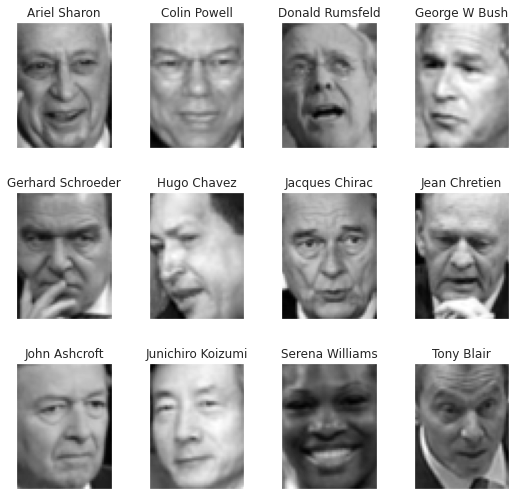

In [ ]:
# get the index of one picture of each person
unique_pic = [np.where(lfw_people.target==n)[0][0] for n in np.arange(12)]

# look at them
plot_gallery(lfw_people.images[unique_pic], names, h, w)

Mostly politicians, all with Wikipedia pages in case you are interested

In [ ]:
# get images as n dimensional array
photos = lfw_people.data
print("""
    There are still {0} images, now each represented 
    as a {1}-dimensional array.
    """.format(*photos.shape))


    There are still 1560 images, now each represented 
    as a 2914-dimensional array.
    


Use SVM for face recognition. Split data into a training and a test set to evaluate ability to correctly recognize faces. Using sklearn handy train_test_split function.

In [ ]:
# get the labels of each photograph
labels = lfw_people.target

# split into a training and testing set
photos_train, photos_test, labels_train, labels_test = \
    model_selection.train_test_split(photos, labels, test_size=0.25, 
                                     random_state=42)
print("""
    Our training and test datasets have
    {0} and {1} photographs, respectively.
    """.format(photos_train.shape[0], photos_test.shape[0]))


    Our training and test datasets have
    1170 and 390 photographs, respectively.
    


Training an SVM using data points of 2914 dimensions will take a while. However all human faces are somewhat similar, so probably don't need all those dimensions. What can we do to get rid of features that would not contribute very much to tell faces apart? i.e. how do we reduce the number of dimensions while preserving the variance? Principal Component Analysis. So getting rid of some dimensions. Start with 10% of the original number and figure out how many dimensions needed.

In [ ]:
# 10% of the dimensions
n_components = int(photos.shape[1] * 0.1)

# apply dimensionality reduction
pca = PCA(n_components=n_components, svd_solver='randomized',
          whiten=True).fit(photos_train)

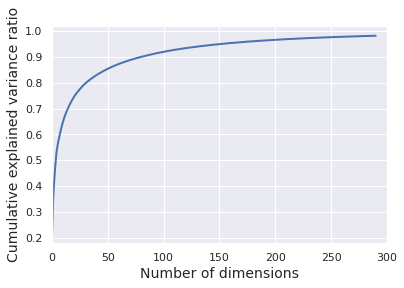

In [ ]:
# compute cumulative sum of explained variance ratios
cum_exp_var = np.cumsum(pca.explained_variance_ratio_)

# look at it
plt.plot(cum_exp_var)
plt.xlabel('Number of dimensions')
plt.ylabel('Cumulative explained variance ratio')
plt.xlim(0,300);

 Don't need that many dimensions. For speed, go with 50 for now, which should get about 80% of the variance.

In [ ]:
n_components = 50

# apply dimensionality reduction
pca = PCA(n_components=n_components, svd_solver='randomized',
          whiten=True).fit(photos_train)
cum_exp_var = np.cumsum(pca.explained_variance_ratio_)

print("""
    {0} features explain {1:.2f}% of the variance.
    """.format(n_components, cum_exp_var[-1]*100))

# Project the data to the lower dimensional planes
photos_train_pca = pca.transform(photos_train)
photos_test_pca = pca.transform(photos_test)


    50 features explain 85.15% of the variance.
    


Plot a slice of transformed data to get a sense of what they are now. X-axis has no meaning. Just plotting each of the new dimensions of datapoints as an  x,y  pair, where  y  is the dimensional value and  x  is just a meaningless dimension number.


    We still have 1170 datapoints in our training set, 
    now each represented as a 50-dimensional array.
    


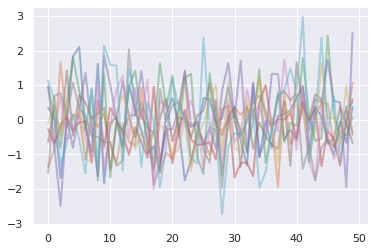

In [ ]:
plt.plot(photos_test_pca[:10].transpose(), alpha=0.5);

print("""
    We still have {0} datapoints in our training set, 
    now each represented as a {1}-dimensional array.
    """.format(*photos_train_pca.shape))

See what the principal components look like by reshaping them back into photographs.

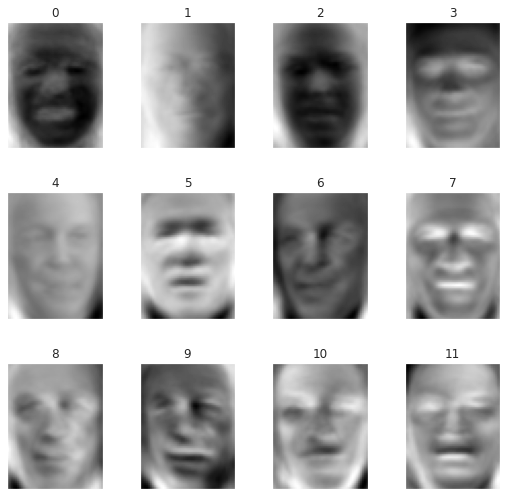

In [ ]:
# get the eigenfaces
eigenfaces = pca.components_.reshape((n_components, h, w))

# number them for plot
n_eigenfaces = np.arange(eigenfaces.shape[0])
plot_gallery(eigenfaces, n_eigenfaces, h, w)

Some of the components that make the faces in the photographs most different. Because of their resemblance to faces when arranged in the above shape, and their utility in face recognition, they have the special name of eigenfaces. They can be linearly combined to reconstruct images in the original training set.

We are now all set to train our classifier. We will use an SVM with an RBF kernel, which takes two parameters,  C  and  γ .

γ  is the free parameter of the RBF kernel, which is defined as:
K(x,x′)=exp(−γ||x−x′||2)
 
where  γ=1/2σ^2 
A small  γ  means large variance, which increases the influence of a single training example; the inverse is true for large  γ .  C  is the parameter for the soft margin cost function, and tunes the shape of the decision surface. Low  C  gives a large minimum margin, and high  C  gives a low minimum margin. In other words, it represents the trade-off between misclassification and simplicity of the support vector.

To figure out good parameter values for our data, we will explore a logarithmic grid with basis 10 using GridSearchCV, which computes a score for each pair of parameters and returns the classifier trained with the best value pair. Finally, we will automatically adjust class weights to be inversely proportional to class frequencies by using the "balanced" keyword argument.

In [ ]:
C_range = np.logspace(-1, 5, 4)
gamma_range = np.logspace(-3, 0, 4)
param_grid = dict(gamma=gamma_range, C=C_range)
clf = model_selection.GridSearchCV(SVC(kernel='rbf', class_weight='balanced'),
                                   param_grid)
clf = clf.fit(photos_train_pca, labels_train)

Looking at the scores for each pair of parameter values

The best parameters are {'C': 10.0, 'gamma': 0.01} with a score of 0.80


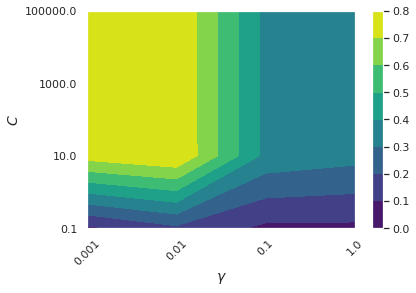

In [ ]:
scores = clf.cv_results_['mean_test_score'].reshape(len(C_range), 
                                                    len(gamma_range))

plt.contourf(scores, cmap=plt.cm.viridis)
plt.colorbar()
plt.xticks(np.arange(len(gamma_range)), gamma_range, rotation=45)
plt.yticks(np.arange(len(C_range)), C_range)
plt.ylabel(r'$C$')
plt.xlabel(r'$\gamma$')
print('The best parameters are {0} with a score of {1:.2f}'.format(
        clf.best_params_, clf.best_score_))

SVM is trained to recognize faces. To see how we are doing,use the classifier to label the test set, i.e. recognize faces. It is important that we don't test the classifier on the training set, as that will overestimate predictive ability. For reference, show one picture of each predicted person. 

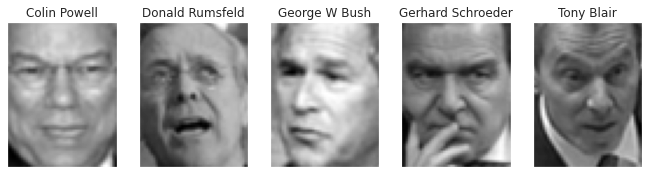

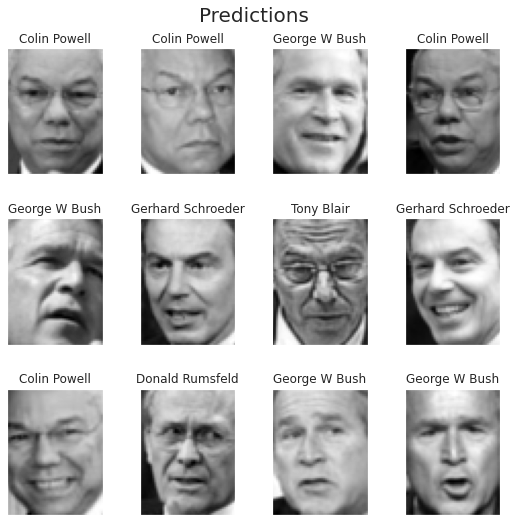

In [ ]:
np.random.seed(10)

# predict labels of our test set
labels_pred = clf.predict(photos_test_pca)

# get indices to randomly look at our predictions
r_ind = np.random.choice(photos_test.shape[0], size=12, replace=False)

# get pictures and respective predictions to look at
s_photos = photos_test[r_ind]
labels_pred_sample = labels_pred[r_ind]
names_pred = names[labels_pred_sample]

# get labels and photos of each person for reference
labels_unique = np.unique(labels_pred_sample)
names_true = names[labels_unique]
photos_true = [np.where(lfw_people.target==n)[0][0] for n in labels_unique]
n_col = len(photos_true)

# plot one picture of each person predicted and shown
plot_gallery(lfw_people.images[photos_true], names_true, h, w, 
             n_row=1, n_col=n_col)

# plot predictions
plot_gallery(s_photos, names_pred, h, w, n_row=3, n_col=4, 
             fig_title="Predictions")

Be more quantitative and get some numbers using the handy classification report function.

In [ ]:
print(metrics.classification_report(labels_test, labels_pred, target_names=names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.62      0.81      0.70        16
     Colin Powell       0.84      0.88      0.86        66
  Donald Rumsfeld       0.57      0.63      0.60        27
    George W Bush       0.90      0.87      0.89       140
Gerhard Schroeder       0.52      0.54      0.53        24
      Hugo Chavez       0.87      0.76      0.81        17
   Jacques Chirac       0.50      0.40      0.44        10
    Jean Chretien       0.86      0.86      0.86        14
    John Ashcroft       0.70      0.88      0.78        16
Junichiro Koizumi       1.00      0.82      0.90        11
  Serena Williams       0.86      0.67      0.75         9
       Tony Blair       0.73      0.68      0.70        40

         accuracy                           0.79       390
        macro avg       0.75      0.73      0.73       390
     weighted avg       0.80      0.79      0.79       390



Precision is the ability not to label as positive a sample that is negative, and recall the ability to find all the positive samples. The F-score is the weighted (harmonic) mean of the precision and recall. All these values range between [0,1] with 1 being the best value. Finally, support is the number of occurrences correctly labeled in each class.

Increase accuracy by increasing the number of components to get a higher explained variance at a speed cost. The training time scales linearly with the number of features. Not too bad for having used only a small number of features (out of the original 2914) and only a few lines of code.